In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Training samples: 60000
Test samples: 10000
Using device: cuda


In [2]:
torch.manual_seed(42)


train_subset, _ = torch.utils.data.random_split(
    train_dataset,
    [5000, len(train_dataset) - 5000]
)

test_subset, _ = torch.utils.data.random_split(
    test_dataset,
    [1000, len(test_dataset) - 1000]
)

print("Training subset samples:", len(train_subset))
print("Test subset samples:", len(test_subset))

Training subset samples: 5000
Test subset samples: 1000


In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False
)

In [4]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [9]:
class MLP(nn.Module):

    def __init__(self, dropout_p=0.0):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Dropout(dropout_p),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(dropout_p),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [10]:
model = MLP().to(device)

print(model)
print("Model device:", next(model.parameters()).device)

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.0, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)
Model device: cuda:0


In [7]:
# ============================================================
# 6. TRAIN + EVALUATE FUNCTION
# ============================================================

def train_model(dropout_p, epochs=50):

    # Create a fresh model
    model = MLP(dropout_p).to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # Store results for every epoch
    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    train_f1_scores = []
    test_f1_scores = []


    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(epochs):

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------

        model.train()

        running_loss = 0.0

        train_predictions = []
        train_labels = []


        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            # Add batch loss
            running_loss += loss.item()

            # Get predicted classes
            predictions = outputs.argmax(dim=1)

            train_predictions.extend(
                predictions.cpu().numpy()
            )

            train_labels.extend(
                labels.cpu().numpy()
            )


        # ----------------------------------------------------
        # TRAINING METRICS
        # ----------------------------------------------------

        train_loss = running_loss / len(train_loader)

        train_accuracy = (
            sum(
                p == l
                for p, l in zip(
                    train_predictions,
                    train_labels
                )
            )
            / len(train_labels)
        )

        train_f1 = f1_score(
            train_labels,
            train_predictions,
            average="macro"
        )


        # ----------------------------------------------------
        # TESTING
        # ----------------------------------------------------

        model.eval()

        test_running_loss = 0.0

        test_predictions = []
        test_labels = []


        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Forward pass
                outputs = model(images)

                # Calculate loss
                loss = criterion(outputs, labels)

                test_running_loss += loss.item()

                # Get predictions
                predictions = outputs.argmax(dim=1)

                test_predictions.extend(
                    predictions.cpu().numpy()
                )

                test_labels.extend(
                    labels.cpu().numpy()
                )


        # ----------------------------------------------------
        # TEST METRICS
        # ----------------------------------------------------

        test_loss = test_running_loss / len(test_loader)

        test_accuracy = (
            sum(
                p == l
                for p, l in zip(
                    test_predictions,
                    test_labels
                )
            )
            / len(test_labels)
        )

        test_f1 = f1_score(
            test_labels,
            test_predictions,
            average="macro"
        )


        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        train_f1_scores.append(train_f1)
        test_f1_scores.append(test_f1)


        # ----------------------------------------------------
        # PRINT RESULTS
        # ----------------------------------------------------

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Test Acc: {test_accuracy:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Test F1: {test_f1:.4f}"
        )


    # Return everything we measured
    return {
        "model": model,

        "train_losses": train_losses,
        "test_losses": test_losses,

        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,

        "train_f1_scores": train_f1_scores,
        "test_f1_scores": test_f1_scores
    }

In [11]:
# ============================================================
# 7. TRAIN PLAIN MLP
# ============================================================

print("\n==============================")
print("TRAINING WITHOUT DROPOUT")
print("==============================\n")

results_no_dropout = train_model(
    dropout_p=0.0,
    epochs=50
)


TRAINING WITHOUT DROPOUT

Epoch 01/50 | Train Loss: 1.1921 | Test Loss: 0.7332 | Train Acc: 0.5886 | Test Acc: 0.7010 | Train F1: 0.5669 | Test F1: 0.6624
Epoch 02/50 | Train Loss: 0.6922 | Test Loss: 0.5914 | Train Acc: 0.7450 | Test Acc: 0.7880 | Train F1: 0.7431 | Test F1: 0.7806
Epoch 03/50 | Train Loss: 0.5753 | Test Loss: 0.4884 | Train Acc: 0.7956 | Test Acc: 0.8310 | Train F1: 0.7944 | Test F1: 0.8189
Epoch 04/50 | Train Loss: 0.5295 | Test Loss: 0.4824 | Train Acc: 0.8104 | Test Acc: 0.8210 | Train F1: 0.8097 | Test F1: 0.8077
Epoch 05/50 | Train Loss: 0.4829 | Test Loss: 0.4324 | Train Acc: 0.8242 | Test Acc: 0.8460 | Train F1: 0.8251 | Test F1: 0.8301
Epoch 06/50 | Train Loss: 0.4598 | Test Loss: 0.4445 | Train Acc: 0.8302 | Test Acc: 0.8320 | Train F1: 0.8304 | Test F1: 0.8241
Epoch 07/50 | Train Loss: 0.4338 | Test Loss: 0.4199 | Train Acc: 0.8414 | Test Acc: 0.8510 | Train F1: 0.8422 | Test F1: 0.8398
Epoch 08/50 | Train Loss: 0.4133 | Test Loss: 0.4053 | Train Acc: 0.84

In [12]:
# ============================================================
# 8. TRAIN MLP WITH DROPOUT
# ============================================================

print("\n==============================")
print("TRAINING WITH DROPOUT (p=0.5)")
print("==============================\n")

results_dropout = train_model(
    dropout_p=0.5,
    epochs=50
)


TRAINING WITH DROPOUT (p=0.5)

Epoch 01/50 | Train Loss: 1.6451 | Test Loss: 0.9207 | Train Acc: 0.4006 | Test Acc: 0.6710 | Train F1: 0.3826 | Test F1: 0.6178
Epoch 02/50 | Train Loss: 1.0517 | Test Loss: 0.7241 | Train Acc: 0.6090 | Test Acc: 0.6970 | Train F1: 0.5969 | Test F1: 0.6617
Epoch 03/50 | Train Loss: 0.8884 | Test Loss: 0.6187 | Train Acc: 0.6836 | Test Acc: 0.7800 | Train F1: 0.6789 | Test F1: 0.7452
Epoch 04/50 | Train Loss: 0.8072 | Test Loss: 0.5657 | Train Acc: 0.7040 | Test Acc: 0.7780 | Train F1: 0.6962 | Test F1: 0.7371
Epoch 05/50 | Train Loss: 0.7445 | Test Loss: 0.5264 | Train Acc: 0.7304 | Test Acc: 0.8000 | Train F1: 0.7227 | Test F1: 0.7563
Epoch 06/50 | Train Loss: 0.6926 | Test Loss: 0.5109 | Train Acc: 0.7478 | Test Acc: 0.8040 | Train F1: 0.7389 | Test F1: 0.7657
Epoch 07/50 | Train Loss: 0.6880 | Test Loss: 0.4977 | Train Acc: 0.7564 | Test Acc: 0.8210 | Train F1: 0.7483 | Test F1: 0.7850
Epoch 08/50 | Train Loss: 0.6566 | Test Loss: 0.4743 | Train Acc:

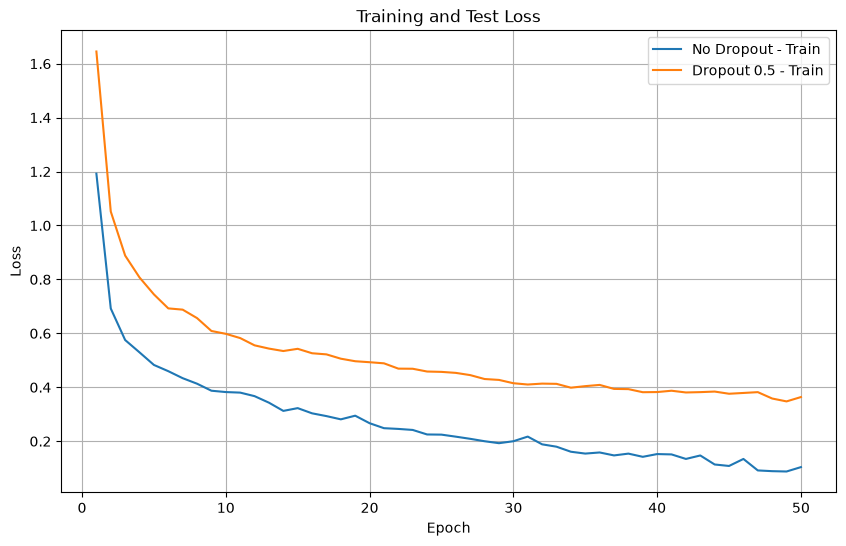

In [15]:
# ============================================================
# 9. PLOT LOSS CURVES
# ============================================================

epochs = range(1, 51)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_no_dropout["train_losses"],
    label="No Dropout - Train"
)


plt.plot(
    epochs,
    results_dropout["train_losses"],
    label="Dropout 0.5 - Train"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid()

plt.show()


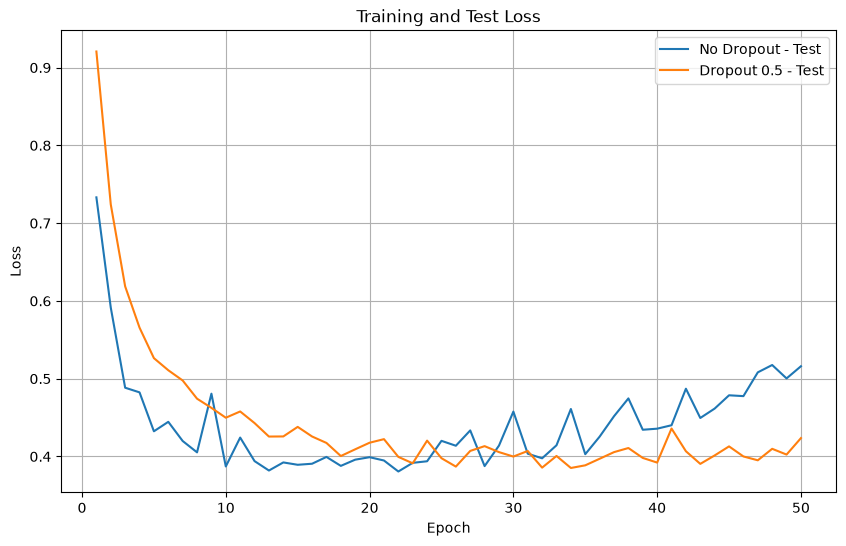

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_no_dropout["test_losses"],
    label="No Dropout - Test"
)

plt.plot(
    epochs,
    results_dropout["test_losses"],
    label="Dropout 0.5 - Test"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid()

plt.show()

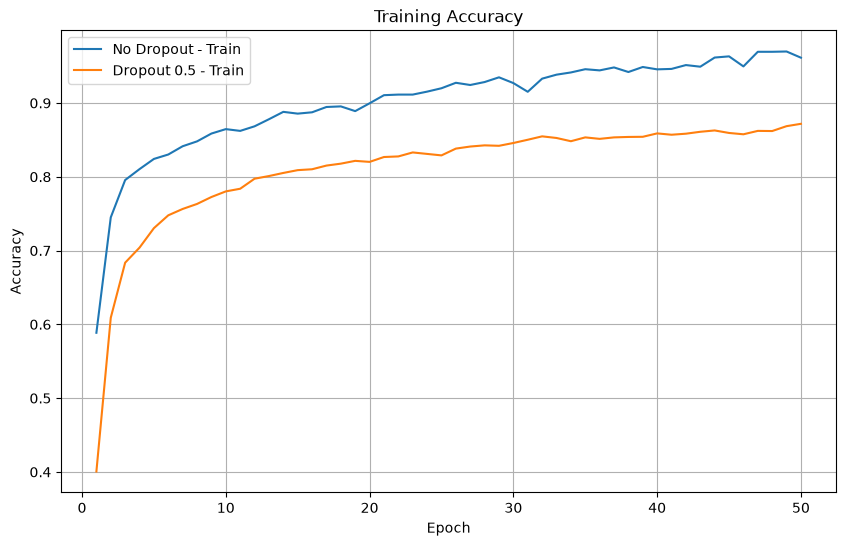

In [18]:
# ============================================================
# 10. PLOT ACCURACY CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_no_dropout["train_accuracies"],
    label="No Dropout - Train"
)


plt.plot(
    epochs,
    results_dropout["train_accuracies"],
    label="Dropout 0.5 - Train"
)



plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.grid()

plt.show()


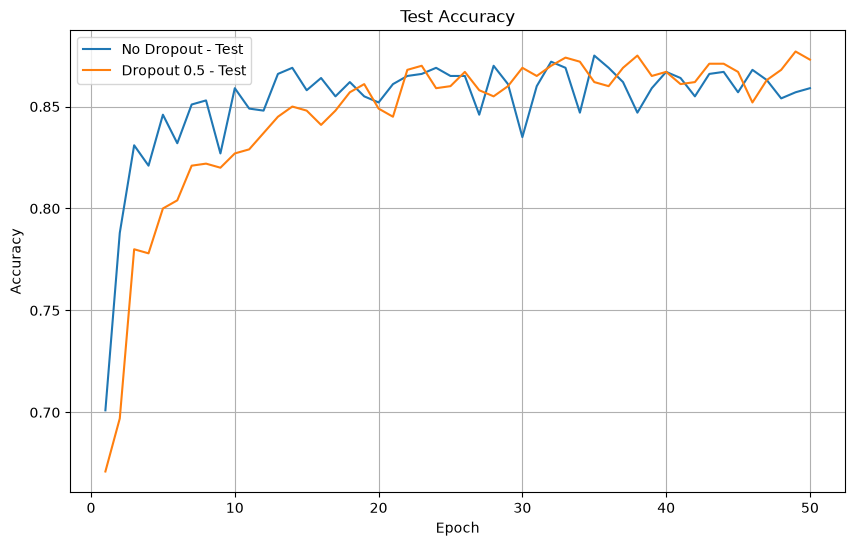

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_no_dropout["test_accuracies"],
    label="No Dropout - Test"
)

plt.plot(
    epochs,
    results_dropout["test_accuracies"],
    label="Dropout 0.5 - Test"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy")
plt.legend()
plt.grid()

plt.show()

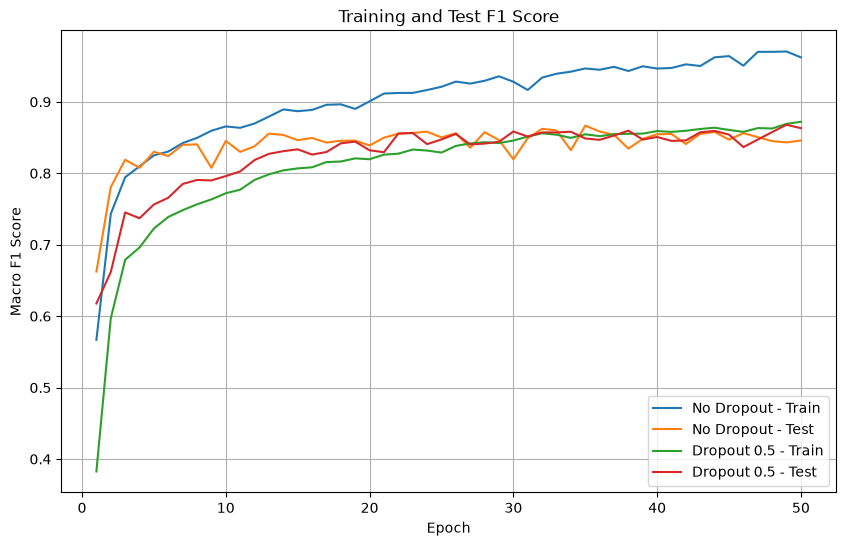

In [20]:
# ============================================================
# 11. PLOT F1 CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    results_no_dropout["train_f1_scores"],
    label="No Dropout - Train"
)

plt.plot(
    epochs,
    results_no_dropout["test_f1_scores"],
    label="No Dropout - Test"
)

plt.plot(
    epochs,
    results_dropout["train_f1_scores"],
    label="Dropout 0.5 - Train"
)

plt.plot(
    epochs,
    results_dropout["test_f1_scores"],
    label="Dropout 0.5 - Test"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")
plt.title("Training and Test F1 Score")
plt.legend()
plt.grid()

plt.show()

In [21]:
import matplotlib.pyplot as plt


# ============================================================
# 1. DROPOUT VALUES TO TEST
# ============================================================

dropout_values = [0.1, 0.25, 0.5, 0.75]

dropout_results = {}


# ============================================================
# 2. TRAIN A MODEL FOR EACH DROPOUT VALUE
# ============================================================

for dropout_p in dropout_values:

    print("\n" + "=" * 60)
    print(f"TRAINING WITH DROPOUT p = {dropout_p}")
    print("=" * 60)

    results = train_model(
        dropout_p=dropout_p,
        epochs=50
    )

    dropout_results[dropout_p] = results


TRAINING WITH DROPOUT p = 0.1
Epoch 01/50 | Train Loss: 1.2815 | Test Loss: 0.7585 | Train Acc: 0.5334 | Test Acc: 0.6830 | Train F1: 0.5101 | Test F1: 0.6281
Epoch 02/50 | Train Loss: 0.7656 | Test Loss: 0.5711 | Train Acc: 0.7104 | Test Acc: 0.7890 | Train F1: 0.7039 | Test F1: 0.7730
Epoch 03/50 | Train Loss: 0.6424 | Test Loss: 0.5542 | Train Acc: 0.7662 | Test Acc: 0.7850 | Train F1: 0.7639 | Test F1: 0.7581
Epoch 04/50 | Train Loss: 0.5816 | Test Loss: 0.4632 | Train Acc: 0.7940 | Test Acc: 0.8310 | Train F1: 0.7925 | Test F1: 0.8090
Epoch 05/50 | Train Loss: 0.5320 | Test Loss: 0.4724 | Train Acc: 0.8158 | Test Acc: 0.8220 | Train F1: 0.8145 | Test F1: 0.8127
Epoch 06/50 | Train Loss: 0.4991 | Test Loss: 0.4602 | Train Acc: 0.8166 | Test Acc: 0.8290 | Train F1: 0.8168 | Test F1: 0.8066
Epoch 07/50 | Train Loss: 0.4673 | Test Loss: 0.4156 | Train Acc: 0.8336 | Test Acc: 0.8440 | Train F1: 0.8345 | Test F1: 0.8333
Epoch 08/50 | Train Loss: 0.4412 | Test Loss: 0.4170 | Train Acc: 

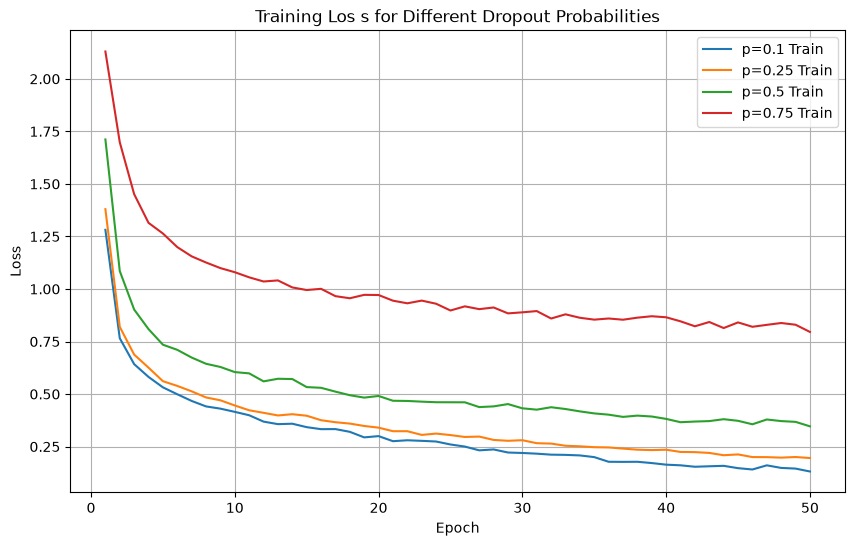

In [22]:
epochs = range(1, 51)

plt.figure(figsize=(10, 6))

for dropout_p in dropout_values:

    plt.plot(
        epochs,
        dropout_results[dropout_p]["train_losses"],
        label=f"p={dropout_p} Train"
    )

    


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Los s for Different Dropout Probabilities")

plt.legend()
plt.grid()

plt.show()

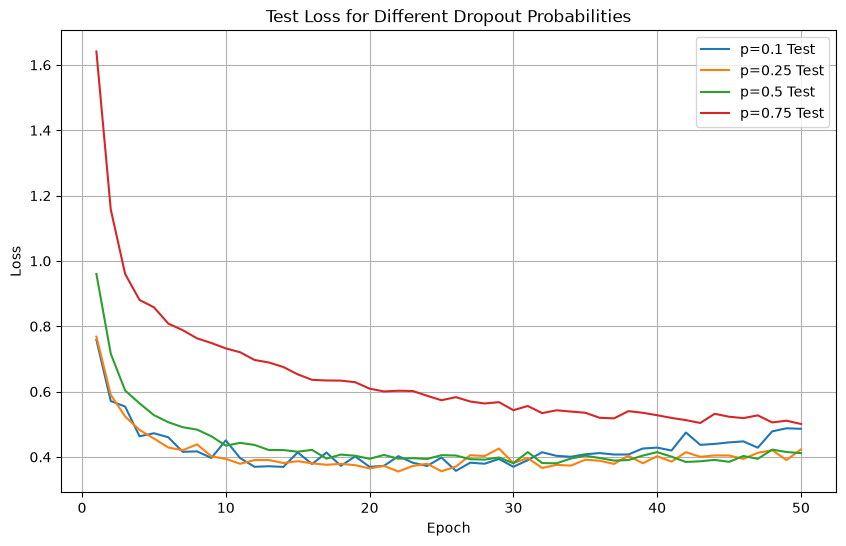

In [24]:
epochs = range(1, 51)

plt.figure(figsize=(10, 6))

for dropout_p in dropout_values:


    plt.plot(
        epochs,
        dropout_results[dropout_p]["test_losses"],
        label=f"p={dropout_p} Test"
    )


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Test Loss for Different Dropout Probabilities")

plt.legend()
plt.grid()

plt.show()

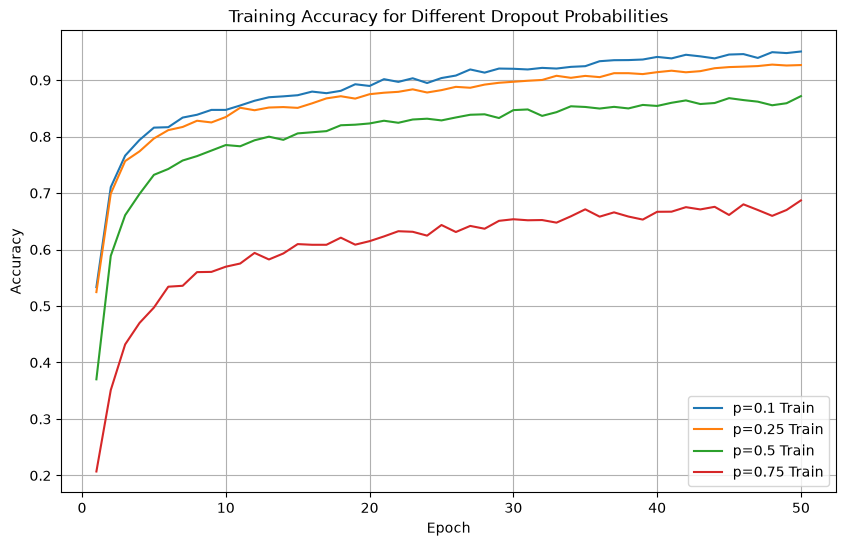

In [25]:
plt.figure(figsize=(10, 6))

for dropout_p in dropout_values:

    plt.plot(
        epochs,
        dropout_results[dropout_p]["train_accuracies"],
        label=f"p={dropout_p} Train"
    )

    


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy for Different Dropout Probabilities")

plt.legend()
plt.grid()

plt.show()

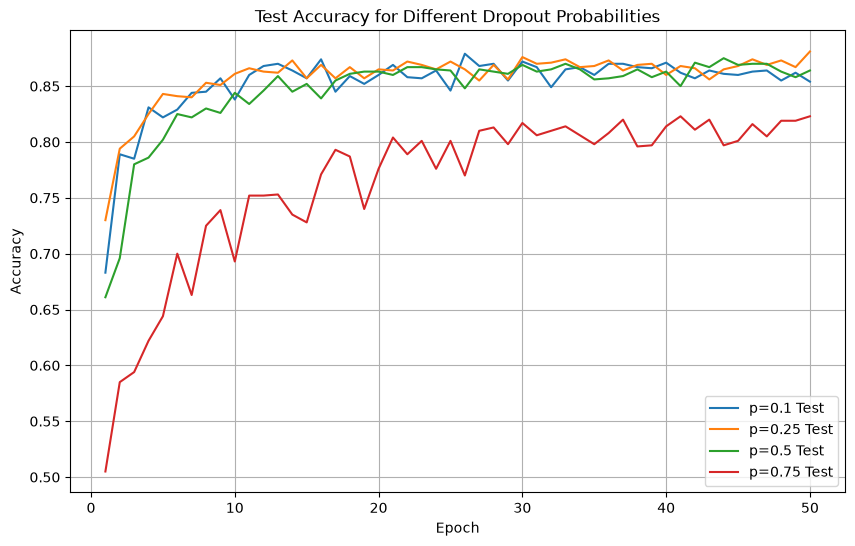

In [26]:
plt.figure(figsize=(10, 6))

for dropout_p in dropout_values:

    

    plt.plot(
        epochs,
        dropout_results[dropout_p]["test_accuracies"],
        label=f"p={dropout_p} Test"
    )


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy for Different Dropout Probabilities")

plt.legend()
plt.grid()

plt.show()

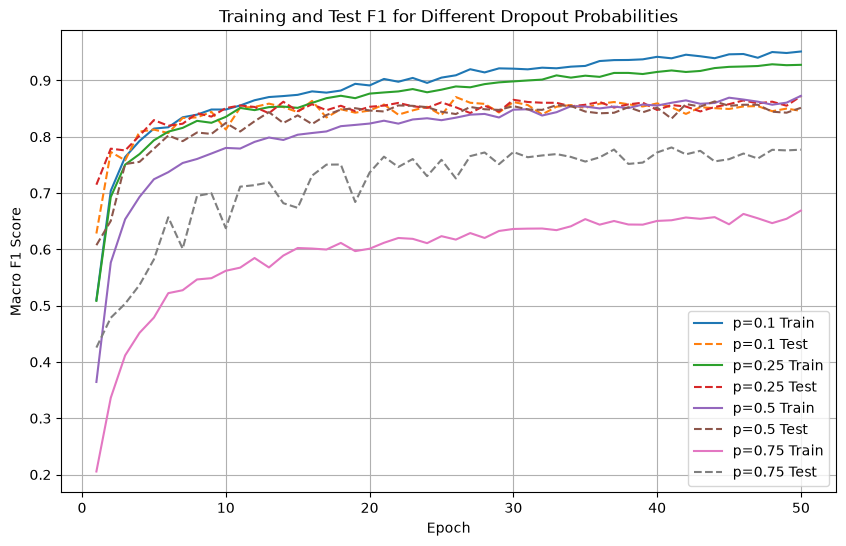

In [27]:
plt.figure(figsize=(10, 6))

for dropout_p in dropout_values:

    plt.plot(
        epochs,
        dropout_results[dropout_p]["train_f1_scores"],
        label=f"p={dropout_p} Train"
    )

    plt.plot(
        epochs,
        dropout_results[dropout_p]["test_f1_scores"],
        linestyle="--",
        label=f"p={dropout_p} Test"
    )


plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")
plt.title("Training and Test F1 for Different Dropout Probabilities")

plt.legend()
plt.grid()

plt.show()

The dropout probability of 0.25 produced the best performance, achieving the highest test accuracy of approximately 88%. A dropout probability of 0.1 achieved around 86% test accuracy, while 0.5 achieved a similar accuracy of around 86%. The highest dropout probability, 0.75, performed significantly worse, with test accuracy around 82%.

As the dropout probability increases, training performance decreases because more neurons are randomly deactivated during training. Consequently, the gap between training and test performance generally becomes smaller, indicating reduced overfitting. However, very high dropout such as 0.75 appears to cause excessive regularization: the model cannot learn the training data effectively, resulting in substantially lower training accuracy and also lower test accuracy. Therefore, moderate dropout, particularly 0.25 in this experiment, provides the best balance between reducing overfitting and retaining sufficient model capacity.